In [22]:
import os
import pandas as pd
ruta_base = "C:/Users/USER/Documents/Trabajo/Cedulas/imagenes_cedula_peq"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)

for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            label = os.path.basename(carpeta_actual)
            data.append({"Path": ruta_completa, "Label": label,"Angle":0})

# Crear el DataFrame
df = pd.DataFrame(data)
df['Label_decode'], uniques = pd.factorize(df["Label"])
stratiffy=[i for i in uniques]
print(df.head())
df.to_excel("df_oritation.xlsx")


                                                Path            Label  Angle  \
0  C:/Users/USER/Documents/Trabajo/Cedulas/imagen...  Cedula_Amarilla      0   
1  C:/Users/USER/Documents/Trabajo/Cedulas/imagen...  Cedula_Amarilla      0   
2  C:/Users/USER/Documents/Trabajo/Cedulas/imagen...  Cedula_Amarilla      0   
3  C:/Users/USER/Documents/Trabajo/Cedulas/imagen...  Cedula_Amarilla      0   
4  C:/Users/USER/Documents/Trabajo/Cedulas/imagen...  Cedula_Amarilla      0   

   Label_decode  
0             0  
1             0  
2             0  
3             0  
4             0  


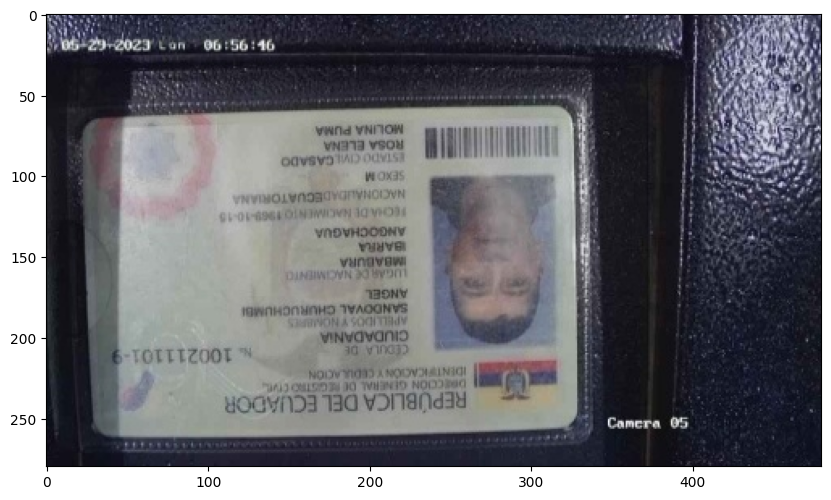

Ángulo estimado: 71.01°


In [16]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
def detectar_angulo(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Binarización adaptativa
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)
    
    # Contornos
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    angles = []
    for cnt in contours:
        if cv2.contourArea(cnt) < 100:
            continue
        rect = cv2.minAreaRect(cnt)
        angle = rect[-1]
        if angle < -45:
            angle = 90 + angle
        angles.append(angle)
    
    if angles:
        return np.mean(angles)
    return 0

# Cargar imagen
img = cv2.imread(df["Path"][0])
img_show=Image.fromarray(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.figure(figsize=(10,10))
plt.imshow(img_show)
plt.show()
angulo = detectar_angulo(img)
print(f"Ángulo estimado: {angulo:.2f}°")


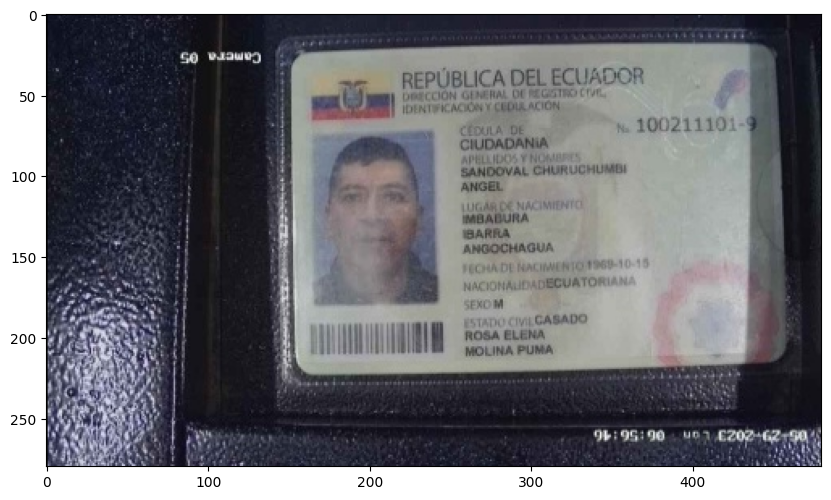

In [17]:
import cv2

escala=1
# Obtener dimensiones
(h, w) = img.shape[:2]
centro = (w // 2, h // 2)

# Crear la matriz de rotación: ángulo en grados y escala
M = cv2.getRotationMatrix2D(centro, -180, escala)

# Aplicar la rotación
imagen_rotada = cv2.warpAffine(img, M, (w, h))

img_show=Image.fromarray(cv2.cvtColor(imagen_rotada,cv2.COLOR_BGR2RGB))
plt.figure(figsize=(10,10))
plt.imshow(img_show)
plt.show()
